In [3]:
import pandas as pd

# Cargamos el archivo (usamos 'nrows' para probar primero con poco)
df = pd.read_csv('../archive/Reviews.csv', nrows=1000)

In [7]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [8]:
print(df.shape)


(1000, 10)


In [9]:
df['Score'].describe()

count    1000.000000
mean        4.179000
std         1.325412
min         1.000000
25%         4.000000
50%         5.000000
75%         5.000000
max         5.000000
Name: Score, dtype: float64

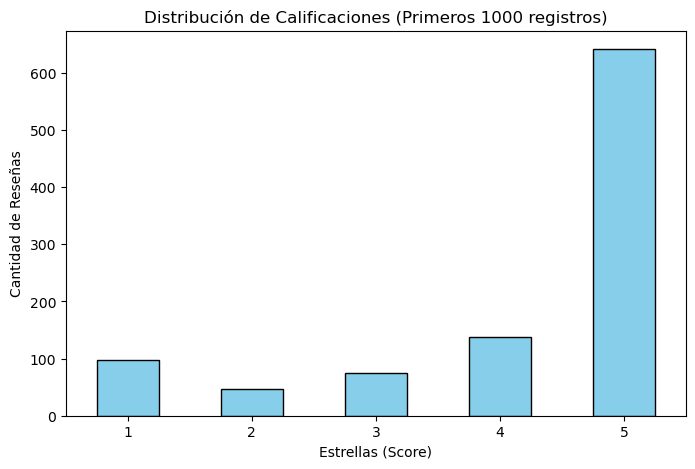

In [3]:
import matplotlib.pyplot as plt

# 1. Contamos cuántas veces aparece cada puntuación
counts = df['Score'].value_counts().sort_index()

# 2. Creamos la gráfica de barras
plt.figure(figsize=(8, 5))
counts.plot(kind='bar', color='skyblue', edgecolor='black')

# 3. Personalizamos con títulos y etiquetas
plt.title('Distribución de Calificaciones (Primeros 1000 registros)')
plt.xlabel('Estrellas (Score)')
plt.ylabel('Cantidad de Reseñas')
plt.xticks(rotation=0) # Para que los números de abajo no salgan de lado

# 4. Mostramos la gráfica
plt.show()

In [4]:
# Convertimos 'Time' a formato fecha (Datetime)
df['Time'] = pd.to_datetime(df['Time'], unit='s')

# Extraemos solo el año para facilitar el análisis
df['Year'] = df['Time'].dt.year

# Veamos cómo quedaron los datos
print(df[['Time', 'Year', 'Score']].head())

        Time  Year  Score
0 2011-04-27  2011      5
1 2012-09-07  2012      1
2 2008-08-18  2008      4
3 2011-06-13  2011      2
4 2012-10-21  2012      5


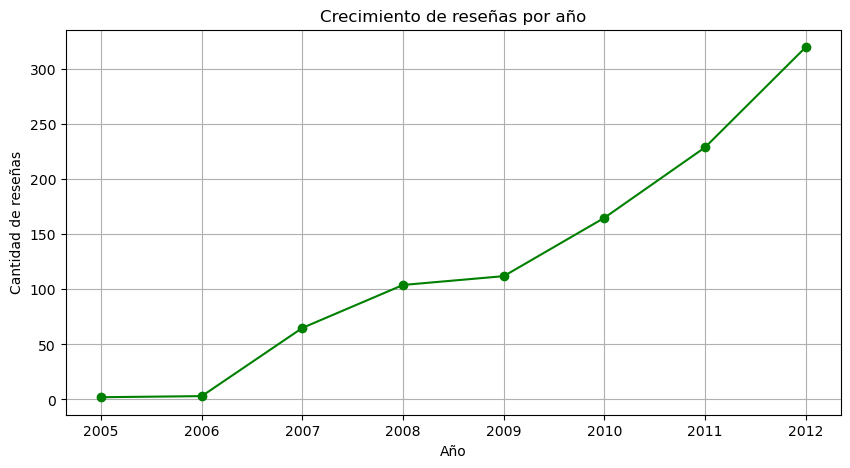

In [5]:
# Contamos cuántas reseñas hay por año
reviews_per_year = df['Year'].value_counts().sort_index()

# Graficamos
plt.figure(figsize=(10, 5))
reviews_per_year.plot(kind='line', marker='o', color='green')

plt.title('Crecimiento de reseñas por año')
plt.xlabel('Año')
plt.ylabel('Cantidad de reseñas')
plt.grid(True)
plt.show()

In [6]:
# 1. Filtramos el dataframe: solo filas donde Score sea igual a 1
peores_resenas = df[df['Score'] == 1]

# 2. Mostramos el 'Summary' (título) y el 'Text' (detalle) de las primeras 5
for i, row in peores_resenas.head(5).iterrows():
    print(f"--- Reseña # {i} ---")
    print(f"RESUMEN: {row['Summary']}")
    print(f"DETALLE: {row['Text'][:200]}...") # Cortamos a 200 caracteres para que no sea eterno
    print("\n")
    

--- Reseña # 1 ---
RESUMEN: Not as Advertised
DETALLE: Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. Not sure if this was an error or if the vendor intended to represent the product as "Jumbo"....


--- Reseña # 12 ---
RESUMEN: My Cats Are Not Fans of the New Food
DETALLE: My cats have been happily eating Felidae Platinum for more than two years. I just got a new bag and the shape of the food is different. They tried the new food when I first put it in their bowls and n...


--- Reseña # 26 ---
RESUMEN: Nasty No flavor
DETALLE: The candy is just red , No flavor . Just  plan and chewy .  I would never buy them again...


--- Reseña # 50 ---
RESUMEN: Don't like it
DETALLE: This oatmeal is not good. Its mushy, soft, I don't like it. Quaker Oats is the way to go....


--- Reseña # 62 ---
RESUMEN: stale product.
DETALLE: Arrived in 6 days and were so stale i could not eat any of the 6 bags!!...


